## 1. An overview of the Dataset including the Dataset Characteristics and Exploratory Data Analysis, Data Preprocessing, and performance of different models.

- **Dataset Characteristics:** CIC-IDS2017 dataset contains network traffic data for the development and evaluation of intrusion detection systems. The dataset is designed to be representative of modern network traffic and includes more than 2.8 million network packets captured over a period of seven days in a real network environment. The dataset includes normal traffic and seven different attack scenarios: Brute Force, Heartbleed, Botnet, DoS, DDoS, Web Attack and Infiltration. The dataset is highly imbalanced. The majority of records belongs to the 'Benign' class and relatively few records belongs to the other classes. The dataset consists of 2830743 rows and 79 columns. In these columns, 78 of them are features that are numerical and the 'label' column is categorical.

- **Exploratory Data Analysis:** This dataset have many duplicate values (308381), which creates bias that is not good for the machine learning model. The number of missing values and infinite values on two columns 'Flow Bytes/s' and 'Flow Packets/s' are very few comparing to the size of the dataset which is only 0.06% (1564). However, the values were handled using appropriate methods.

- **Data Preprocessing:** We dropped the duplicates, replaced any infinite values (positive or negative) with NaN (not a number) and filled the missing values with median values. Since we have a very large dataset, the initial memory usage is quite high leading to session crashes. We later worked our way through this by down casting data types based on the min and max values available. We try to reduce the memory usages that is helpful for our model.

- **Data Analysis:** We grouped similar attacks together to analyze the dataset and identify patterns in the different types of attacks. We took a sample from the population (20%). Later we did some data analysis which consist of plotting various kinds of charts, correlation matrices etc. to see the relationships between features, types of attacks present in the dataset etc. In our analysis, we noticed there are a good number of features that are strongly, even directly correlated with other features (both positive and negative). This is an issue it introduces multi-collinearity which can highly impact the machine learning models that we will develop later.

  Also, as the dataset is quite huge and has more than 70 features, it would be extremely difficult to train models using limited resources. In order to overcome this issue, we used PCA (Principal Component Analysis) to reduece dimensions. We played with the number of components to see how much information we can preserve. We monitored the '*explained_variance_ratio_*' to make sure we retain most informations. However, it was a bit challenging to reduce dimensions while preserving the information to train the models. We performed StandardScaler before performing Incremental PCA.

- **ML Models:** It is worth mentioning the fact that the following dataset is highly imbalanced. So, we created a balanced dataset out of this with our domain knowledge to train various ML models. Since our dataset is quite large and has a reasonable amount of samples to train and test different ML models using various classification algorithms (Logistic Regression, Support Vector Machine for Binary Classification and Random Forest Classifier, Decision Tree, K Nearest Neighbours for Multi-class Classification).

  For binary classifications, we trained the models to distinguish between normal traffic and anomalous traffic. This means it will only predict whether an intrusion is taking place or not. Alternatively, using the multi-class classification algorithms, we further extended our prediction capabilities to identify which type of attack or intrusion is taking place. We tried both binary classifications and multi-class classifications to see how the data holds up. Later we cross-validated, evaluated and compared those models to see which one works better or worse.

- **Performance Evaluation:** After training multiple machine learning models, we proceeded to evaluate their respective performances. Our evaluation process involved comparing the accuracy, recall, f1-score and confusion matrix of each model. Through analysis of the results, we were able to see which model performed the best and which performed worse.

## 2.	Dataset Characteristics and Exploratory Data Analysis

### 2.1 Load, View Data and Show Analysis on Rows and Columns

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
sns.set(style='darkgrid')
import matplotlib.pyplot as plt

In [32]:
# Loading the dataset
data1 = pd.read_csv('https://storage.googleapis.com/mlskripsi/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
data2 = pd.read_csv('https://storage.googleapis.com/mlskripsi/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
data3 = pd.read_csv('https://storage.googleapis.com/mlskripsi/Friday-WorkingHours-Morning.pcap_ISCX.csv')
data4 = pd.read_csv('https://storage.googleapis.com/mlskripsi/Monday-WorkingHours.pcap_ISCX.csv')
data5 = pd.read_csv('https://storage.googleapis.com/mlskripsi/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
data6 = pd.read_csv('https://storage.googleapis.com/mlskripsi/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
data7 = pd.read_csv('https://storage.googleapis.com/mlskripsi/Tuesday-WorkingHours.pcap_ISCX.csv')
data8 = pd.read_csv('https://storage.googleapis.com/mlskripsi/Wednesday-workingHours.pcap_ISCX.csv')

In [33]:
data_list = [data1, data2, data3, data4, data5, data6, data7, data8]

print('Data dimensions: ')
for i, data in enumerate(data_list, start = 1):
  rows, cols = data.shape
  print(f'Data{i} -> {rows} rows, {cols} columns')

Data dimensions: 
Data1 -> 225745 rows, 79 columns
Data2 -> 286467 rows, 79 columns
Data3 -> 191033 rows, 79 columns
Data4 -> 529918 rows, 79 columns
Data5 -> 288602 rows, 79 columns
Data6 -> 170366 rows, 79 columns
Data7 -> 445909 rows, 79 columns
Data8 -> 692703 rows, 79 columns


In [34]:
data = pd.concat(data_list)
rows, cols = data.shape

print('New dimension:')
print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')

New dimension:
Number of rows: 2830743
Number of columns: 79
Total cells: 223628697


In [35]:
# Deleting dataframes after concating to save memory
for d in data_list: del d

In [36]:
# Renaming the columns by removing leading/trailing whitespace
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)

In [37]:
data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2830743 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow I

In [39]:
pd.options.display.max_rows = 80

print('Overview of Columns:')
data.describe().transpose()

Overview of Columns:


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.000000e+00,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-1.300000e+01,155.000000,31316.000000,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.000000e+00,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.000000e+00,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.000000e+00,12.000000,62.000000,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.000000e+00,0.000000,123.000000,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.000000e+00,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.000000e+00,0.000000,2.000000,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2830743.0,5.820194e+01,1.860912e+02,0.000000e+00,6.000000,34.000000,5.000000e+01,5.940857e+03
Fwd Packet Length Std,2830743.0,6.891013e+01,2.811871e+02,0.000000e+00,0.000000,0.000000,2.616295e+01,7.125597e+03


In [40]:
pd.options.display.max_columns = 80
data

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.00000,0,0,0.0,0.0,4.000000e+06,666666.666700,3.0,0.000000,3,3,3,3.00000,0.00000,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.00000,6,6,6.0,0.0,1.100917e+05,18348.623850,109.0,0.000000,109,109,0,0.00000,0.00000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.00000,6,6,6.0,0.0,2.307692e+05,38461.538460,52.0,0.000000,52,52,0,0.00000,0.00000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.00000,6,6,6.0,0.0,3.529412e+05,58823.529410,34.0,0.000000,34,34,0,0.00000,0.00000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.00000,0,0,0.0,0.0,4.000000e+06,666666.666700,3.0,0.000000,3,3,3,3.00000,0.00000,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692698,53,32215,4,2,112,152,28,28,28.0,0.00000,76,76,76.0,0.0,8.194940e+03,186.248642,6443.0,13617.579480,30780,3,30832,10277.33333,17755.84381,30780,4,3,3.0,0.0,3,3,0,0,0,0,80,64,124.165761,62.082881,28,76,41.714286,23.421602,548.571429,0,0,0,0,0,0,0,0,0,48.666667,28.0,76.0,80,0,0,0,0,0,0,4,112,2,152,-1,-1,3,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
692699,53,324,2,2,84,362,42,42,42.0,0.00000,181,181,181.0,0.0,1.376543e+06,12345.679010,108.0,183.597386,320,2,2,2.00000,0.00000,2,2,2,2.0,0.0,2,2,0,0,0,0,40,40,6172.839506,6172.839506,42,181,97.600000,76.133435,5796.300000,0,0,0,0,0,0,0,0,1,122.000000,42.0,181.0,40,0,0,0,0,0,0,2,84,2,362,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
692700,58030,82,2,1,31,6,31,0,15.5,21.92031,6,6,6.0,0.0,4.512195e+05,36585.365850,41.0,52.325902,78,4,4,4.00000,0.00000,4,4,0,0.0,0.0,0,0,1,0,0,0,64,20,24390.243900,12195.121950,0,31,17.000000,16.3

### 2.2 Pre-processing

#### Data cleaning

In [41]:
dups = data[data.duplicated()]
print(f'Number of duplicates: {len(dups)}')

Number of duplicates: 308381


In [42]:
data.drop_duplicates(inplace = True)
data.shape

(2522362, 79)

In [43]:
missing_val = data.isna().sum()
print(missing_val.loc[missing_val > 0])

Flow Bytes/s    353
dtype: int64


In [44]:
# Checking for infinity values
numeric_cols = data.select_dtypes(include = np.number).columns
inf_count = np.isinf(data[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [45]:
# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values: {data.isna().sum().sum()}')

data.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {data.isna().sum().sum()}')

Initial missing values: 353
Missing values after processing infinite values: 3128


In [46]:
missing = data.isna().sum()
print(missing.loc[missing > 0])

Flow Bytes/s      1564
Flow Packets/s    1564
dtype: int64


In [47]:
# Calculating missing value percentage in the dataset
mis_per = (missing / len(data)) * 100
mis_table = pd.concat([missing, mis_per.round(2)], axis = 1)
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})

print(mis_table.loc[mis_per > 0])

                Missing Values  Percentage of Total Values
Flow Bytes/s              1564                        0.06
Flow Packets/s            1564                        0.06


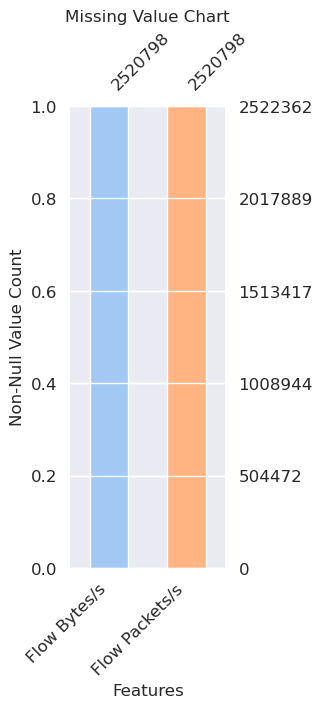

In [48]:
sns.set_palette('pastel')
colors = sns.color_palette()

missing_vals = [col for col in data.columns if data[col].isna().any()]

fig, ax = plt.subplots(figsize = (2, 6))
msno.bar(data[missing_vals], ax = ax, fontsize = 12, color = colors)
ax.set_xlabel('Features', fontsize = 12)
ax.set_ylabel('Non-Null Value Count', fontsize = 12)
ax.set_title('Missing Value Chart', fontsize = 12)
plt.show()

In [49]:
#Dealing with missing data

data.index.duplicated().sum()
data = data.reset_index(drop=True)
data.index.duplicated().sum()

np.int64(0)

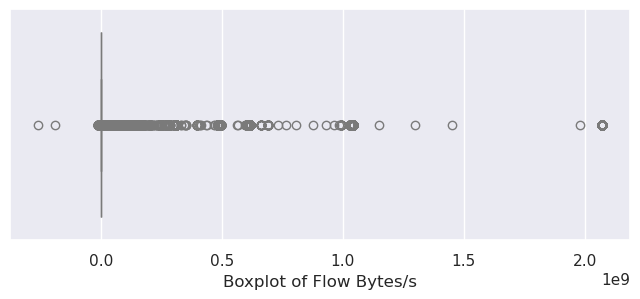

In [50]:
plt.figure(figsize = (8, 3))
sns.boxplot(x = data['Flow Bytes/s'])
plt.xlabel('Boxplot of Flow Bytes/s')
plt.show()

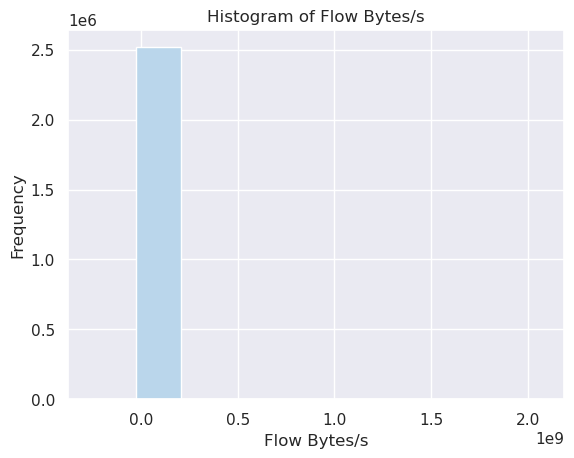

In [51]:
colors = sns.color_palette('Blues')
plt.hist(data['Flow Bytes/s'], color = colors[1])
plt.title('Histogram of Flow Bytes/s')
plt.xlabel('Flow Bytes/s')
plt.ylabel('Frequency')
plt.show()

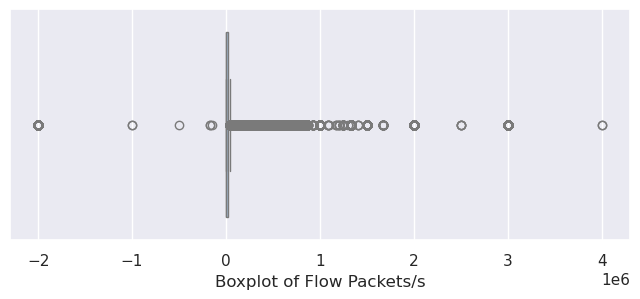

In [52]:
plt.figure(figsize = (8, 3))
sns.boxplot(x = data['Flow Packets/s'])
plt.xlabel('Boxplot of Flow Packets/s')
plt.show()

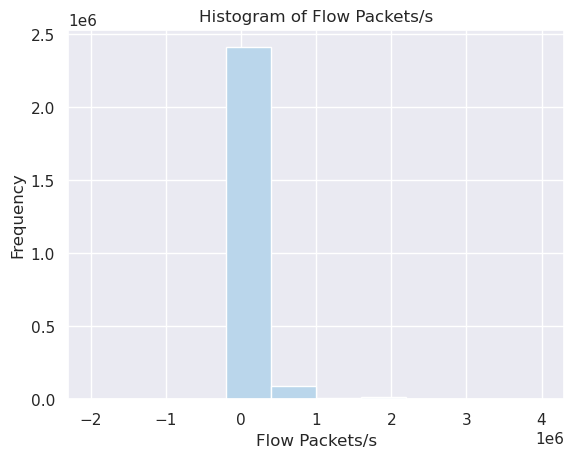

In [53]:
plt.hist(data['Flow Packets/s'], color = colors[1])
plt.title('Histogram of Flow Packets/s')
plt.xlabel('Flow Packets/s')
plt.ylabel('Frequency')
plt.show()

In [54]:
med_flow_bytes = data['Flow Bytes/s'].median()
med_flow_packets = data['Flow Packets/s'].median()

print('Median of Flow Bytes/s: ', med_flow_bytes)
print('Median of Flow Packets/s: ', med_flow_packets)

Median of Flow Bytes/s:  3715.0378579999997
Median of Flow Packets/s:  69.742244285


In [55]:
# Filling missing values with median
data['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
data['Flow Packets/s'].fillna(med_flow_packets, inplace = True)

/tmp/ipykernel_15135/1818654804.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
/tmp/ipykernel_15135/1818654804.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [56]:
print('Number of \'Flow Bytes/s\' missing values:', data['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', data['Flow Packets/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


In [57]:
data['Label'].unique()

array(['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'FTP-Patator', 'SSH-Patator',
       'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye',
       'Heartbleed'], dtype=object)

In [58]:
# Types of attacks & normal instances (BENIGN)
data['Label'].value_counts()

Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [59]:
# Creating a dictionary that maps each label to its attack type
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
data['Attack Type'] = data['Label'].map(attack_map)

In [60]:
data['Attack Type'].value_counts()

Attack Type
BENIGN          2096484
DoS              193748
DDoS             128016
Port Scan         90819
Brute Force        9152
Web Attack         2143
Bot                1953
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

In [61]:
data.drop('Label', axis = 1, inplace = True)

In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Attack Number'] = le.fit_transform(data['Attack Type'])

print(data['Attack Number'].unique())

[0 3 7 1 6 8 2 4 5]


In [63]:
# Printing corresponding attack type for each encoded value
encoded_values = data['Attack Number'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {le.inverse_transform([val])[0]}")

0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS
5: Heartbleed
6: Infiltration
7: Port Scan
8: Web Attack


In [64]:
# Dropping columns with only one unique value
num_unique = data.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = data[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index(['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [65]:
data.shape

(2522362, 72)

In [66]:
# Columns after removing non variant columns
data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',

In [67]:
# Standardizing the dataset
from sklearn.preprocessing import StandardScaler

features = data.drop('Attack Type', axis = 1)
attacks = data['Attack Type']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [69]:
from sklearn.decomposition import IncrementalPCA

size = len(features.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features, len(features) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}')

information retained: 99.10%


In [70]:
transformed_features = ipca.transform(scaled_features)
new_data = pd.DataFrame(transformed_features, columns = [f'PC{i+1}' for i in range(size)])
new_data['Attack Type'] = attacks.values

In [71]:
new_data

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Attack Type
0,-2.342624,-0.052298,0.504211,0.485507,3.855629,0.348871,-0.019741,0.188815,0.403044,-0.684848,-0.337774,-0.269430,1.638557,0.699348,-1.737427,-0.455208,-0.009110,0.698045,-1.146341,-0.038705,-0.274496,-0.537010,-0.972338,-1.732727,-0.368285,-0.193235,0.301605,-0.057750,0.708267,-0.519851,-0.019738,0.019368,0.001561,0.089105,0.145161,BENIGN
1,-2.280414,-0.048420,0.464075,0.326280,2.010696,-0.160659,-0.016288,-0.782336,-0.877113,2.642360,0.400889,0.416599,0.821478,-0.188875,1.002563,-0.154065,-0.000149,0.344234,-0.505050,-0.028792,-0.418109,0.663125,-0.971828,-0.021131,0.347741,-0.124900,0.637541,0.264713,0.424668,0.777337,0.226709,-0.056356,0.001445,0.039094,-0.018781,BENIGN
2,-2.292376,-0.048803,0.468996,0.335508,2.091590,-0.152980,-0.016553,-0.771036,-0.865295,2.616471,0.390848,0.404926,0.953970,-0.156477,0.930821,-0.104226,0.003585,0.396930,-0.372353,0.012582,-0.386904,0.574511,-0.962043,0.090762,0.401913,-0.155027,0.626067,0.248296,0.427604,0.774363,0.221421,-0.054006,0.001442,0.038152,-0.021474,BENIGN
3,-2.282338,-0.050015,0.461216,0.275313,2.022544,-0.126161,-0.015992,-0.746451,-0.828858,2.490310,0.368683,0.382190,1.003722,-0.109424,0.807234,-0.033061,0.008099,0.441830,-0.187163,0.068527,-0.338932,0.505456,-0.913922,0.259467,0.480532,-0.176332,0.488461,0.135361,0.100183,0.796994,0.090680,0.006605,0.001280,0.022889,0.004346,BENIGN
4,-2.342620,-0.052299,0.504213,0.485486,3.855599,0.348862,-0.019743,0.188801,0.403066,-0.684864,-0.337777,-0.269430,1.638544,0.699354,-1.737436,-0.455210,-0.009110,0.698048,-1.146341,-0.038691,-0.274503,-0.537009,-0.972328,-1.732701,-0.368321,-0.193254,0.301563,-0.057790,0.708199,-0.519829,-0.019775,0.019384,0.001561,0.089107,0.145174,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2522357,-2.002105,-0.034293,0.215145,-0.508477,-0.745879,-0.260385,-0.029428,-0.394606,0.264339,-0.400787,-0.075331,-0.018900,-0.580482,0.174576,-0.530497,-0.304803,-0.015860,-0.066174,-0.548363,0.153594,-0.101729,-0.303597,0.078364,0.118103,0.206590,-0.560312,0.089078,-0.321227,-0.017901,0.285133,-0.084826,-0.043931,0.000846,0.015571,-0.485899,BENIGN
2522358,-2.003812,-0.034309,0.146135,-0.690542,-1.381123,-1.054007,-0.085223,-0.674130,1.057300,-0.344313,-0.070618,0.032660,0.024459,0.087736,-0.209454,0.005780,0.009668,0.285633,-0.159738,-0.075873,0.169228,-0.198331,-0.011978,0.381957,-0.013263,0.416031,0.230412,0.277693,0.074158,0.004461,-0.385691,-0.388294,-0.003343,-0.000363,-0.006038,BENIGN
2522359,-2.215530,-0.042031,0.885478,1.141549,4.486869,0.088072,-0.038381,0.681737,1.508917,-0.913415,-0.146236,-0.037220,-2.585760,-0.931366,2.946968,-0.485147,-0.059057,-1.521339,0.324542,0.776912,-0.209974,-0.870282,0.170454,1.111479,-0.023455,0.036623,0.321112,0.293444,1.480825,-0.105217,0.649590,-0.199997,0.001087,0.136220,-0.117175,BENIGN
2522360,-1.943403,-0.035095,0.240121,-0.593804,-0.954136,-0.485936,-0.048465,-0.495453,0.547120,-0.471108,-0.093383,-0.004583,-0.594599,0.195060,-0.572167,-0.315680,-0.013466,0.057686,-0.575879,0.066458,0.006858,-0.421322,0.085339,0.221246,0.244618,-0.371894,0.354063,-0.069318,0.048468,0.366050,-0.337158,-0.278711,-0.001197,0.018488,-0.324749,BENIGN


In [72]:
new_data['Attack Type'].value_counts()

Attack Type
BENIGN          2096484
DoS              193748
DDoS             128016
Port Scan         90819
Brute Force        9152
Web Attack         2143
Bot                1953
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

In [73]:
class_counts = new_data['Attack Type'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = new_data[new_data['Attack Type'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['Attack Type'] == name]
  if len(df) > 2500:
    df = df.sample(n = 5000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)
df['Attack Type'].value_counts()

Attack Type
BENIGN         5000
DoS            5000
DDoS           5000
Port Scan      5000
Brute Force    5000
Web Attack     2143
Bot            1953
Name: count, dtype: int64

In [75]:
from imblearn.over_sampling import SMOTE

X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled, y_upsampled = smote.fit_resample(X, y)

blnc_data = pd.DataFrame(X_upsampled)
blnc_data['Attack Type'] = y_upsampled
blnc_data = blnc_data.sample(frac=1)

blnc_data['Attack Type'].value_counts()

/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Attack Type
Brute Force    5000
Bot            5000
Web Attack     5000
Port Scan      5000
DDoS           5000
BENIGN         5000
DoS            5000
Name: count, dtype: int64

In [76]:
new_data.to_csv('data_bersih.csv', index=False)

In [78]:
blnc_data.to_csv('data_bersih.csv', index=False)

In [80]:
import os
import json
import warnings
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi global & reproduktibilitas
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # kurangi verbosity log TF

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"TensorFlow version : {tf.__version__}")
print(f"Eager execution    : {tf.executing_eagerly()}")

TensorFlow version : 2.20.0
Eager execution    : True


In [ ]:
# -----------------------------------------------------------------------------
# Konfigurasi path dan kolom target (sesuaikan dengan struktur data Anda)
# -----------------------------------------------------------------------------
DATA_PATH = Path("data_bersih.csvdata_bersih.csv")  # TODO: ganti ke path dataset sebenarnya
TARGET_COLUMN = "target"  # TODO: ganti ke nama kolom target di dataset Anda

# -----------------------------------------------------------------------------
# Memuat dataset
# -----------------------------------------------------------------------------
df = pd.read_csv(DATA_PATH)
assert TARGET_COLUMN in df.columns, f"Kolom target '{TARGET_COLUMN}' tidak ditemukan. Perbarui TARGET_COLUMN."

feature_names = [col for col in df.columns if col != TARGET_COLUMN]
X = df[feature_names].to_numpy()
y_raw = df[TARGET_COLUMN]

label_encoder = None
if pd.api.types.is_object_dtype(y_raw) or pd.api.types.is_categorical_dtype(y_raw):
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw)
else:
    y = y_raw.to_numpy()

# -----------------------------------------------------------------------------
# Infer tipe masalah
# -----------------------------------------------------------------------------
def infer_problem_type(y_values: np.ndarray, threshold_unique_for_regression: int = 20) -> str:
    unique_count = np.unique(y_values).size
    if np.issubdtype(y_values.dtype, np.floating) and unique_count > threshold_unique_for_regression:
        return "regression"
    if np.issubdtype(y_values.dtype, np.integer) and unique_count > threshold_unique_for_regression:
        return "regression"
    if unique_count <= 2:
        return "binary"
    return "multiclass"

problem_type = infer_problem_type(y)
num_classes = np.unique(y).size if problem_type != "regression" else 1

if problem_type == "binary":
    problem_spec = {
        "output_units": 1,
        "output_activation": "sigmoid",
        "loss": "binary_crossentropy",
        "metrics": ["accuracy"],
    }
elif problem_type == "multiclass":
    problem_spec = {
        "output_units": num_classes,
        "output_activation": "softmax",
        "loss": "sparse_categorical_crossentropy",
        "metrics": ["accuracy"],
    }
else:
    problem_spec = {
        "output_units": 1,
        "output_activation": "linear",
        "loss": "mse",
        "metrics": [keras.metrics.RootMeanSquaredError(name="rmse")],
    }

print(f"Dataset loaded from : {DATA_PATH}")
print(f"Problem type        : {problem_type}")
print(f"Feature shape       : {X.shape}")
print(f"Target shape        : {y.shape}")
if problem_type != "regression":
    print(f"Number of classes   : {num_classes}")

df.head()